In [39]:
import numpy as np
import pandas as pd
url ='https://raw.githubusercontent.com/campusx-official/placement-project-logistic-regression/refs/heads/main/placement.csv'



## Load the dataframe


In [40]:
df = pd.read_csv(url)

## View the first few rows

In [41]:
print(df.head())

   Unnamed: 0  cgpa     iq  placement
0           0   6.8  123.0          1
1           1   5.9  106.0          0
2           2   5.3  121.0          0
3           3   7.4  132.0          1
4           4   5.8  142.0          0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [43]:
df.shape

(100, 4)

# Steps

# 0. Preprocess| + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model



# 0. Preprocess

In [44]:
df = df.iloc[:,1:]

In [45]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0




# 0. EDA



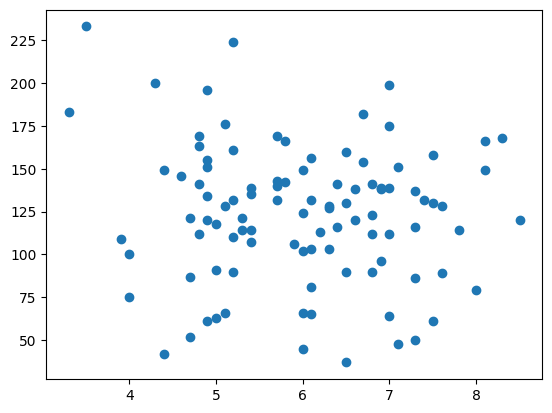

In [46]:
 import matplotlib.pyplot as plt
 plt.scatter(df['cgpa'],df['iq'])

## Student who are placed

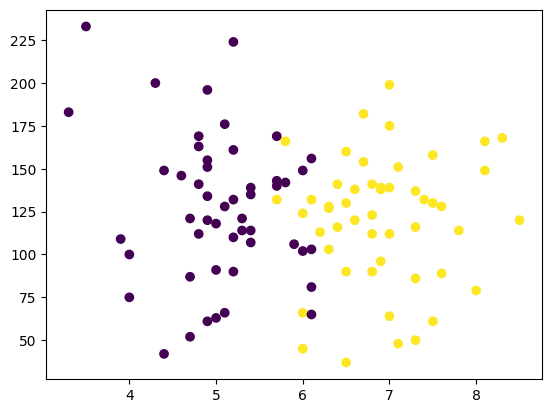

In [47]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

## yellow represents getting placed

## Extract input and output cols

In [48]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [49]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [50]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [51]:
x.shape

(100, 2)

In [52]:
y.shape

(100,)

## train test split

In [53]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)


### Correcting data inconsistency

The previous error indicates an inconsistency in the number of samples between `x_train` and `y_train`. This section will re-run the train-test split and scaling to ensure both training sets have the correct and consistent number of samples (90 in this case).

In [54]:
# Re-run train_test_split to ensure fresh and correct splits
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1, random_state=42) # Added random_state for reproducibility

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (90, 2)
y_train shape: (90,)
x_test shape: (10, 2)
y_test shape: (10,)


In [55]:
# Re-initialize and apply StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Scaling applied successfully.")

Scaling applied successfully.


Now that `x_train` and `y_train` have consistent numbers of samples, you can proceed to train the logistic regression model by running the `clf.fit(x_train, y_train)` cell again.

In [56]:
x_train

array([[-1.73718527, -0.62029848],
       [ 1.45537303,  0.09806189],
       [-0.9390457 , -1.62087186],
       [ 0.03645823,  0.63683217],
       [ 1.1893265 , -0.97947867],
       [-0.14090612,  0.45724208],
       [-0.9390457 ,  0.79076654],
       [ 1.1893265 , -1.90308486],
       [-0.49563482,  0.3802749 ],
       [-1.82586745, -0.38939693],
       [ 1.63273738, -0.26111829],
       [-1.38245657,  0.63683217],
       [ 0.92327998,  1.91961855],
       [ 1.45537303, -0.90251149],
       [ 2.2535126 , -0.10718393],
       [-0.76168135,  1.32953682],
       [-0.9390457 ,  0.25199626],
       [-1.38245657, -2.10833068],
       [-0.76168135, -1.49259322],
       [ 1.1893265 , -0.20980684],
       [ 0.8345978 ,  0.35461917],
       [-0.67299917,  0.9447009 ],
       [-0.14090612,  1.07297954],
       [-0.67299917, -0.87685576],
       [ 0.74591563, -0.31242975],
       [ 1.01196215, -1.95439632],
       [ 0.8345978 , -0.72292139],
       [ 1.8987839 ,  1.07297954],
       [ 0.74591563,

In [57]:
y_train

,placement
18,0
30,1
73,0
33,0
90,1
...,...
60,1
71,1
14,0
92,0


## Scalling

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [59]:
x_train = scaler.fit_transform(x_train)

In [60]:
x_train

array([[-1.73718527, -0.62029848],
       [ 1.45537303,  0.09806189],
       [-0.9390457 , -1.62087186],
       [ 0.03645823,  0.63683217],
       [ 1.1893265 , -0.97947867],
       [-0.14090612,  0.45724208],
       [-0.9390457 ,  0.79076654],
       [ 1.1893265 , -1.90308486],
       [-0.49563482,  0.3802749 ],
       [-1.82586745, -0.38939693],
       [ 1.63273738, -0.26111829],
       [-1.38245657,  0.63683217],
       [ 0.92327998,  1.91961855],
       [ 1.45537303, -0.90251149],
       [ 2.2535126 , -0.10718393],
       [-0.76168135,  1.32953682],
       [-0.9390457 ,  0.25199626],
       [-1.38245657, -2.10833068],
       [-0.76168135, -1.49259322],
       [ 1.1893265 , -0.20980684],
       [ 0.8345978 ,  0.35461917],
       [-0.67299917,  0.9447009 ],
       [-0.14090612,  1.07297954],
       [-0.67299917, -0.87685576],
       [ 0.74591563, -0.31242975],
       [ 1.01196215, -1.95439632],
       [ 0.8345978 , -0.72292139],
       [ 1.8987839 ,  1.07297954],
       [ 0.74591563,

In [61]:
x_test = scaler.fit_transform(x_test)

In [62]:
x_test

array([[ 1.0268429 ,  0.25809017],
       [ 1.70018251,  1.08922801],
       [ 0.01683349,  0.19247403],
       [-0.23566886, -1.14172092],
       [ 1.0268429 , -1.25108116],
       [-1.41401318,  0.60804294],
       [-1.16151082,  0.03936969],
       [-1.16151082,  1.70164536],
       [-0.23566886, -1.60103394],
       [ 0.43767075,  0.10498583]])

## Model training using logistic regression

In [63]:
from sklearn.linear_model import LogisticRegression

In [64]:
clf = LogisticRegression()

In [65]:
clf.fit(x_train,y_train)

LogisticRegression()

## Evaluate the model

In [68]:
y_pred = clf.predict(x_test)

In [67]:
y_test

,placement
83,1
53,1
70,1
45,1
44,1
39,0
22,0
80,0
10,1
0,1


In [69]:
from sklearn.metrics import accuracy_score

In [70]:
accuracy_score(y_test,y_pred)

0.7

<Axes: >

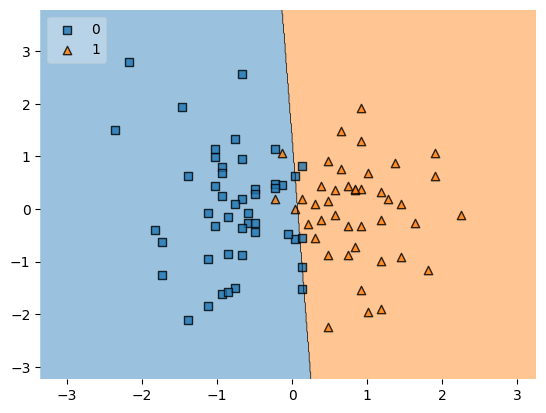

In [72]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [73]:
import pickle

In [74]:
pickle.dump(clf,open('model.pkl','wb'))